[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/07_data_vis/07_6_Correlation_Heatmaps_Pairplot.ipynb)

# 07.6: Correlation, Heatmaps, and Pair Plots

The previous notebooks looked at one pair of variables at a time. But a dataset with six numeric columns has fifteen distinct pairs. Checking each one individually would take fifteen scatter plots. This notebook introduces two tools that show all the pairs at once: the **heatmap** for correlation matrices and the **pair plot** for raw distributions and scatter plots across every combination.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "age", "sibsp", "parch", "fare"]].copy()
df.head()

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


## From correlation table to heatmap

You already know how to compute a correlation matrix from module 06. It gives you the Pearson correlation between every pair of numeric columns, ranging from -1 (perfect negative association) to +1 (perfect positive association).

In [2]:
corr = df.corr(numeric_only=True)
corr.round(2)

,survived,pclass,age,sibsp,parch,fare
survived,1.00,-0.34,-0.08,-0.04,0.08,0.26
pclass,-0.34,1.00,-0.37,0.08,0.02,-0.55
age,-0.08,-0.37,1.00,-0.31,-0.19,0.10
sibsp,-0.04,0.08,-0.31,1.00,0.41,0.16
parch,0.08,0.02,-0.19,0.41,1.00,0.22
fare,0.26,-0.55,0.10,0.16,0.22,1.00


The table has all the information, but scanning it for patterns is slow. The diagonal is always 1.0 (each variable perfectly correlates with itself). The upper and lower triangles mirror each other. You have to visually search for the large positive and negative values.

A **heatmap** maps the correlation values to a color scale, which lets you spot strong correlations at a glance.

Text(0.5, 1.0, 'Correlation matrix: Titanic numeric variables')

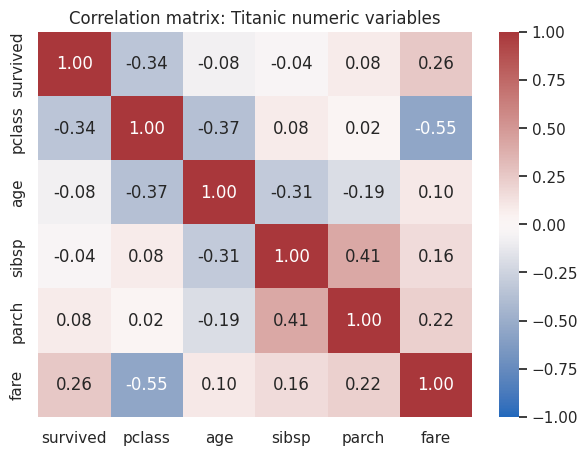

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="vlag",
    vmin=-1, vmax=1, center=0,
    ax=ax
)
ax.set_title("Correlation matrix: Titanic numeric variables")

Now the patterns jump out. Deep red cells indicate strong positive correlations; deep blue cells indicate strong negative correlations; pale cells near white indicate weak correlations.

The standout observations:
- `pclass` and `fare` (dark blue, -0.55): higher class numbers (lower class) go with lower fares. This is expected.
- `pclass` and `survived` (blue, -0.34): higher class number goes with lower survival. Third-class passengers were least likely to survive.
- `fare` and `survived` (light red, +0.26): higher fares go with higher survival, but much of this is driven by the class relationship.
- `sibsp` and `parch` (light red, +0.41): passengers with more siblings/spouses also tended to have more parents/children aboard. Families traveled together.

Three technical choices to note: `cmap="vlag"` is a diverging colormap (blue for negative, red for positive) with white at zero, which is the right choice for correlation data. `center=0` ensures white maps to zero. `vmin=-1, vmax=1` fixes the scale at the theoretical limits of correlation so the colors are directly comparable to what correlation values mean.

## Heatmaps for any 2D numeric matrix

A heatmap works for any rectangular table of numbers, not just correlations. From module 06 you know how to compute a pivot table. Visualizing it as a heatmap turns a table of numbers into an immediately readable grid.

Text(28.75, 0.5, 'Passenger class')

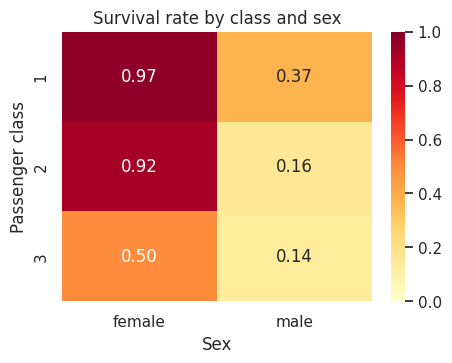

In [4]:
df_full = sns.load_dataset("titanic")
survival_grid = pd.pivot_table(
    df_full,
    values="survived",
    index="pclass",
    columns="sex",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.heatmap(
    survival_grid,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    ax=ax
)
ax.set_title("Survival rate by class and sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Passenger class")

This is the same pivot table you computed in module 06, but as a heatmap the message is instant. The top-left cell (female, first class) is nearly full red (high survival). The bottom-right cell (male, third class) is pale yellow (low survival). You can read the entire class-sex interaction in a single glance.

Note the switch from `"vlag"` to `"YlOrRd"` (yellow to red). This is a sequential colormap, appropriate when the values all have the same sign and the question is just "how much?" Use diverging colormaps (like `"vlag"` or `"coolwarm"`) when the data has a meaningful zero or midpoint that separates two directions.

## The joint plot: one pair, in depth

When you want to examine a single pair of variables in detail, `sns.jointplot()` combines a central scatter plot (or KDE) with marginal histograms on both axes. You get the bivariate relationship and the univariate distributions of each variable in one figure.

Text(0.5, 1.01, 'Age vs fare with marginal distributions')

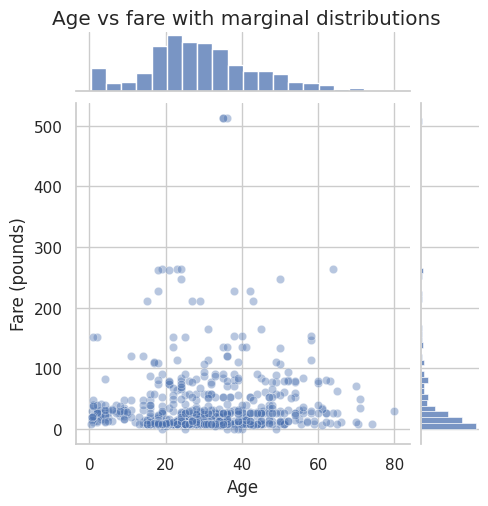

In [5]:
g = sns.jointplot(
    data=df.dropna(subset=["age"]),
    x="age", y="fare",
    kind="scatter",
    alpha=0.4,
    height=5
)
g.set_axis_labels("Age", "Fare (pounds)")
g.figure.suptitle("Age vs fare with marginal distributions", y=1.01)

The central scatter plot shows the bivariate relationship (or lack of one). The top histogram shows the marginal distribution of age; the right histogram shows the marginal distribution of fare. The right histogram immediately confirms the strong right skew of fare that you saw in 07.2.

Switching `kind=` gives different views of the same two variables.

Text(0.5, 1.01, 'Age vs fare: KDE joint distribution')

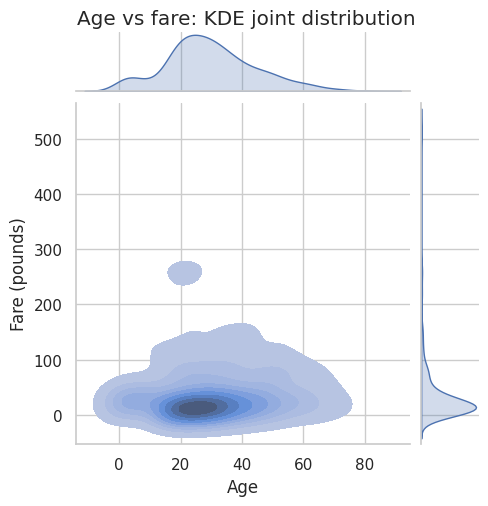

In [6]:
g = sns.jointplot(
    data=df.dropna(subset=["age"]),
    x="age", y="fare",
    kind="kde",
    fill=True,
    height=5
)
g.set_axis_labels("Age", "Fare (pounds)")
g.figure.suptitle("Age vs fare: KDE joint distribution", y=1.01)

The KDE view shows a density estimate: darker contours indicate regions where more passengers are concentrated. The dense cluster in the lower left (young passengers, low fares) confirms that most passengers were 20 to 40 years old and paid under 50 pounds. The diffuse scatter elsewhere reflects the small number of older or high-fare passengers.

## The pair plot: every combination at once

A `sns.pairplot()` creates a grid of charts where every row and column is one variable. Off-diagonal cells show scatter plots (or KDEs) for each pair. Diagonal cells show the univariate distribution of each variable. With six variables, you get a 6x6 grid that shows all 15 unique pairs.

This is the standard first visual scan of a new dataset.

Text(0.5, 1.01, 'Pairwise relationships: selected numeric columns')

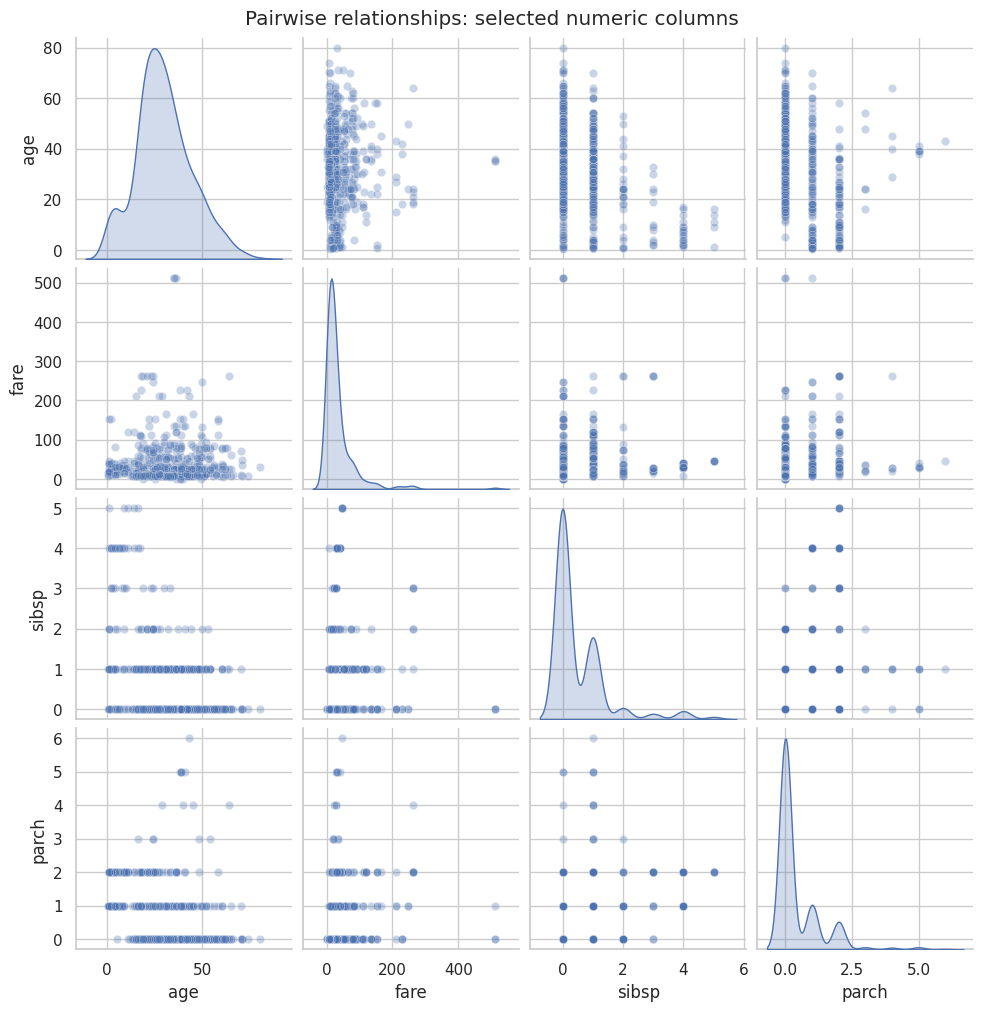

In [7]:
g = sns.pairplot(
    df.dropna(subset=["age"]),
    vars=["age", "fare", "sibsp", "parch"],
    diag_kind="kde",
    plot_kws={"alpha": 0.3}
)
g.figure.suptitle("Pairwise relationships: selected numeric columns", y=1.01)

Reading across any row of scatter plots shows how that variable relates to all others. A few observations:
- Age vs fare (top-right of the upper triangle): no clear pattern, consistent with what you saw in 07.4.
- Sibsp vs parch (bottom-right): a loose positive relationship. Passengers with more siblings also tended to have more children aboard. The clustering reflects families with common sizes.
- The diagonal KDEs confirm the shapes you already know: age is roughly symmetric; fare is strongly right-skewed; sibsp and parch are both right-skewed with most passengers near zero.

Adding `hue=` colors every cell by a grouping variable, which makes patterns visible that raw scatter plots hide.

Text(0.5, 1.01, 'Pairwise relationships, colored by survival')

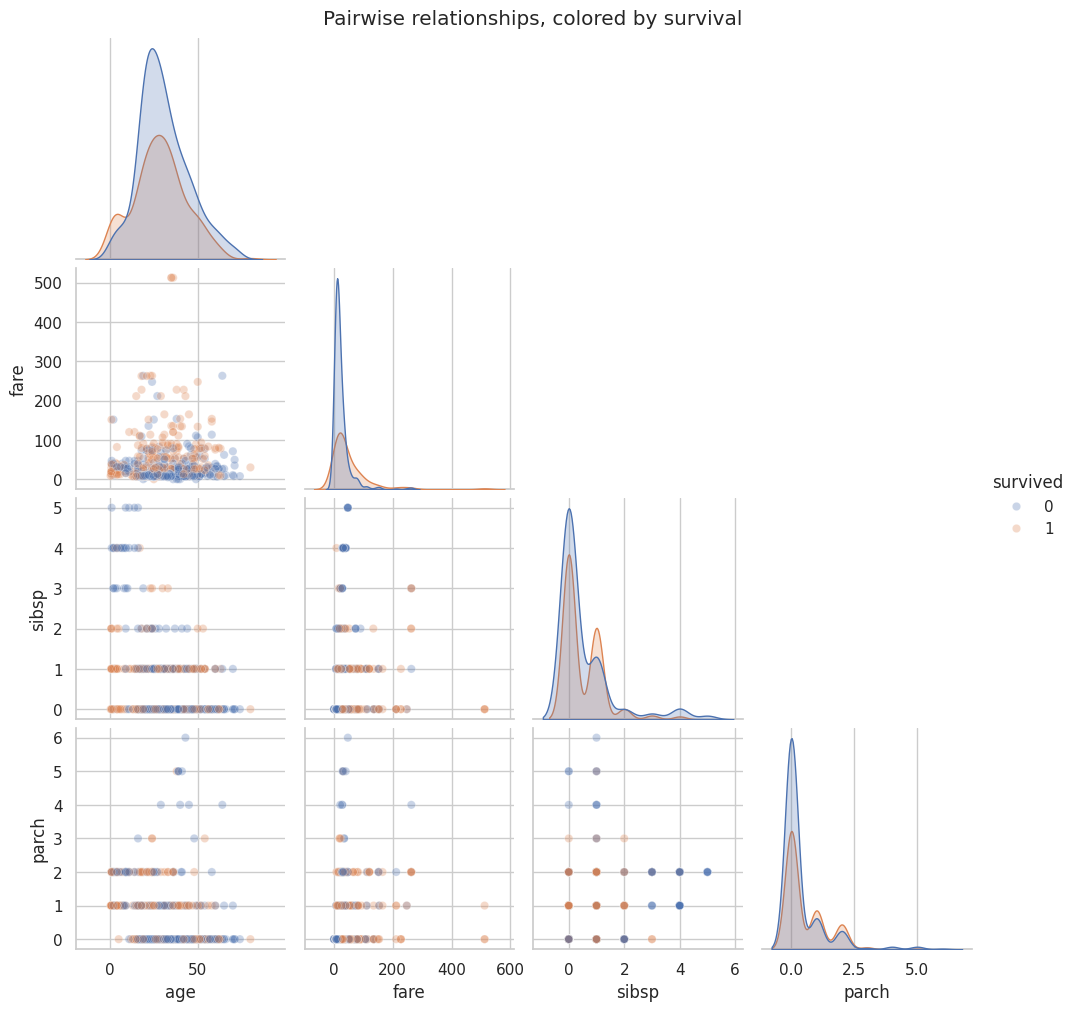

In [8]:
g = sns.pairplot(
    df.dropna(subset=["age"]),
    vars=["age", "fare", "sibsp", "parch"],
    hue="survived",
    diag_kind="kde",
    plot_kws={"alpha": 0.3},
    corner=True
)
g.figure.suptitle("Pairwise relationships, colored by survival", y=1.01)

`corner=True` shows only the lower triangle (each pair appears only once), which halves the visual clutter. With `hue="survived"`, survivors and non-survivors appear in different colors in every cell simultaneously.

A few things stand out: the fare diagonal KDE shows survivors concentrated at higher fares. The age diagonal shows the small elevation of child survivors mentioned in 07.2. The off-diagonal scatter plots confirm that no single pair of variables cleanly separates survivors from non-survivors in two dimensions; the Titanic outcome depended on multiple variables interacting.

That is exactly what the pair plot is for: a fast, broad survey of a dataset that tells you where to look more closely.

## What's next

You now have a complete toolkit of chart types. In 07.7, the focus shifts from what to draw to how to present it: titles, labels, palettes, and saving figures for use outside of Jupyter.